In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [2]:
# 1. Load data
table = pq.read_table('data/daily_weather.parquet')
df = table.to_pandas()
print('Total rows loaded initially:', len(df))

Total rows loaded initially: 27635763


In [3]:
# 2. Filter for the first city
target_city = df['city_name'].unique()[0]
print('Target City:', target_city)
df = df[df['city_name'] == target_city].copy()
print('Rows after city filter:', len(df))

Target City: Asadabad
Rows after city filter: 9572


In [4]:
# 3. Handle dates properly
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').set_index('date')

In [5]:
# 4. Feature engineering
temp_col = 'avg_temp_c'
df['Temp_Rolling_Avg_7D'] = df[temp_col].rolling(window=7).mean()
df['Temp_Lag_1'] = df[temp_col].shift(1)
df['Temp_Lag_7'] = df[temp_col].shift(7)
df['Month'] = df.index.month
df['DayOfWeek'] = df.index.dayofweek

In [6]:
# 5. Clean NaNs specifically for model features
features = ['Temp_Rolling_Avg_7D', 'Temp_Lag_1', 'Temp_Lag_7', 'Month', 'DayOfWeek']
df = df.dropna(subset=features + [temp_col])
print('Rows remaining after feature engineering & dropping NaNs:', len(df))

Rows remaining after feature engineering & dropping NaNs: 9565


R2 Score: 0.9617
RMSE: 1.8138


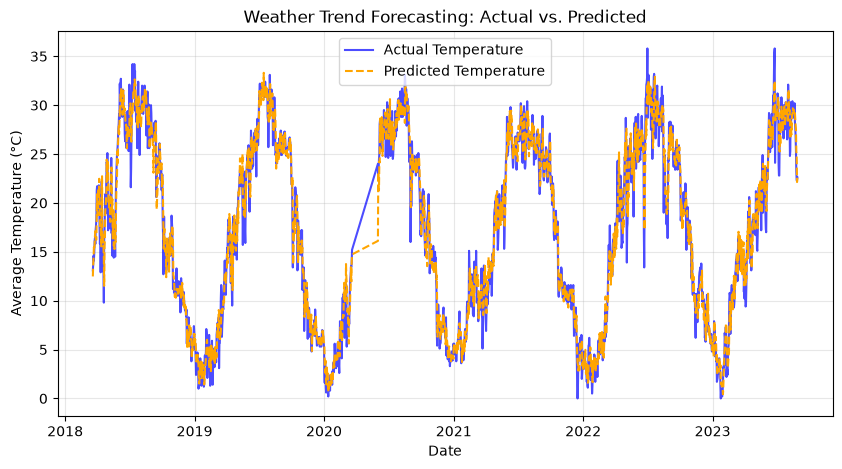

In [7]:
# 6. Train model only if rows exist
if len(df) > 0:
    X = df[features]
    y = df[temp_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    print(f'R2 Score: {r2_score(y_test, predictions):.4f}')
    print(f'RMSE: {np.sqrt(mean_squared_error(y_test, predictions)):.4f}')

    # Save plot
    os.makedirs('assets', exist_ok=True)
    plt.figure(figsize=(10, 5))
    plt.plot(
        y_test.index,
        y_test,
        label='Actual Temperature',
        color='blue',
        alpha=0.7,
    )
    plt.plot(
        y_test.index,
        predictions,
        label='Predicted Temperature',
        color='orange',
        linestyle='--',
    )
    plt.title('Weather Trend Forecasting: Actual vs. Predicted')
    plt.xlabel('Date')
    plt.ylabel('Average Temperature (°C)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('assets/weather_forecast.png', bbox_inches='tight')
    plt.show()
else:
    print('Error: Dataframe is empty. Check your column names or date format.')